Baseline SIR = 只保留感染恢复

没有 awareness

没有 mobility

状态只剩 S,I,R

In [13]:
import numpy as np
import pandas as pd


# =========================================================
# Baseline Model 0: Classical SIR (No mobility, No awareness)
# =========================================================
def main_simulation(Time, N, params):
    """
    Classical baseline SIR model (mean-field style).

    Parameters
    ----------
    Time : int
        Total simulation steps
    N : int
        Number of patches (for consistency with CPS model)
    params : dict
        Model parameters:
        beta : infection rate
        mu   : recovery rate

    Returns
    -------
    history : (Time, 3)
        Global proportions over time: [S, I, R]
    """

    beta = params["beta"]   # infection probability
    mu   = params["mu"]     # recovery probability

    # -------------------------------------------------
    # Initial conditions (consistent with your CPS code)
    # -------------------------------------------------
    S = np.full(N, 0.99)   # Susceptible proportion
    I = np.full(N, 0.01)   # Initial infected proportion
    R = np.zeros(N)        # Recovered proportion

    # Record history: global mean values
    history = np.zeros((Time, 3))

    # -------------------------------------------------
    # Main iteration
    # -------------------------------------------------
    for t in range(Time):

        # Global average state
        history[t, 0] = S.mean()
        history[t, 1] = I.mean()
        history[t, 2] = R.mean()

        # Classical SIR transitions
        new_inf = beta * S * I
        new_rec = mu * I

        # Update states
        S = S - new_inf
        I = I + new_inf - new_rec
        R = R + new_rec

    return history


# =========================================================
# Run simulation + Save CSV
# =========================================================
if __name__ == "__main__":

    # -----------------------------
    # Simulation settings (same as yours)
    # -----------------------------
    Time = 120
    N = 4000

    # -----------------------------
    # Parameter choice (consistent baseline)
    # -----------------------------
    params = {
        # Use beta_U from CPS as baseline infection rate
        "beta": 0.1,

        # Use mu2 from CPS as recovery rate
        "mu": 0.1
    }

    # -----------------------------
    # Run baseline SIR simulation
    # -----------------------------
    history = main_simulation(Time, N, params)

    # -----------------------------
    # Save results to CSV
    # -----------------------------
    df = pd.DataFrame(
        history, 
        columns=["S", "I", "R"]
        )
    
    df.to_csv("baseline_SIR_results.csv", index=False)

    print("Baseline SIR simulation finished.")
    print("Results saved to baseline_SIR_results.csv")
    print(df.head())


Baseline SIR simulation finished.
Results saved to baseline_SIR_results.csv
          S         I         R
0  0.990000  0.010000  0.000000
1  0.989010  0.009990  0.001000
2  0.988022  0.009979  0.001999
3  0.987036  0.009967  0.002997
4  0.986052  0.009954  0.003994


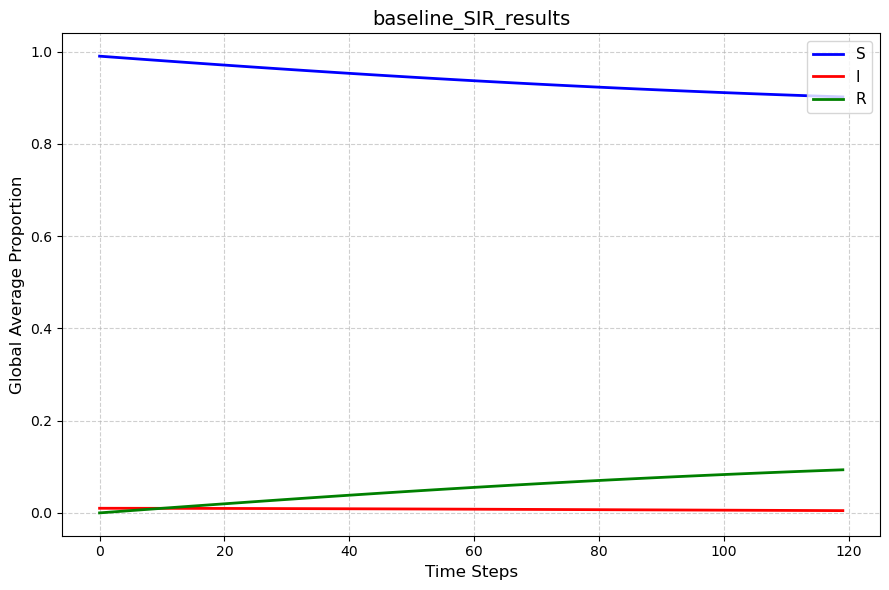

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 1. 读取 SIR 模型的输出 CSV 文件
# ============================================
file_name = "baseline_SIR_results.csv"   # 根据实际文件名修改
df = pd.read_csv(file_name)

# ============================================
# 2. 设置三状态的颜色映射（沿用统一风格）
# ============================================
state_colors = {
    'S': 'blue',      # 易感
    'I': 'red',       # 感染
    'R': 'green'      # 康复
}
state_labels = ['S', 'I', 'R']   # 必须与 df 列顺序一致

# ============================================
# 3. 创建画布并绘制各状态曲线
# ============================================
plt.figure(figsize=(9, 6))

for i, label in enumerate(state_labels):
    plt.plot(
        df.index,                 # 时间步（0 ~ Time-1）
        df[label],               # 该状态的全局平均比例
        label=label,
        color=state_colors[label],
        linewidth=2
    )

# ============================================
# 4. 图表装饰（模板风格）
# ============================================
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Global Average Proportion', fontsize=12)
plt.title('baseline_SIR_results', fontsize=14)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 保存图片（可选）
# plt.savefig('SIR_MIR_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()